In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All tools imported! ✅")

All tools imported! ✅


Created the data

In [2]:
np.random.seed(42)

funnel_data = {
    'Stage' : ['Homepage', 'Programs Page', 'Internship Page', 'Started App', 'Submitted', 'Confirmed'],
    'Users'  : [1000, 720, 480, 310, 180, 95]
}

df = pd.DataFrame(funnel_data)

df['Dropped']   = df['Users'].diff().abs().fillna(0).astype(int)
df['Drop_Rate'] = (df['Dropped'] / df['Users'].shift(1) * 100).fillna(0).round(1)

print(df)

             Stage  Users  Dropped  Drop_Rate
0         Homepage   1000        0        0.0
1    Programs Page    720      280       28.0
2  Internship Page    480      240       33.3
3      Started App    310      170       35.4
4        Submitted    180      130       41.9
5        Confirmed     95       85       47.2


In [4]:
# analysis from the data
total        = df['Users'].iloc[0]
confirmed    = df['Users'].iloc[-1]
conversion   = round(confirmed / total * 100, 1)

# where most people dropped off
worst_stage  = df.loc[df['Drop_Rate'].idxmax(), 'Stage']
worst_rate   = df['Drop_Rate'].max()

# least drop off
best_stage   = df.loc[df[df['Drop_Rate'] > 0]['Drop_Rate'].idxmin(), 'Stage']
best_rate    = df[df['Drop_Rate'] > 0]['Drop_Rate'].min()

print(" FUNNEL ANALYSIS ")
print(f"Total Visitors       : {total}")
print(f"Final Confirmed      : {confirmed}")
print(f"Overall Conversion   : {conversion}%")
print(f"\n🔴 Biggest Bottleneck : {worst_stage} ({worst_rate}% dropped here)")
print(f"🟢 Smoothest Stage    : {best_stage} (only {best_rate}% dropped here)")
print(f"\n💡 Insight: Only {conversion}% of visitors complete the full journey.")
print(f"   Focus on fixing '{worst_stage}' stage first for maximum impact.")

 FUNNEL ANALYSIS 
Total Visitors       : 1000
Final Confirmed      : 95
Overall Conversion   : 9.5%

🔴 Biggest Bottleneck : Confirmed (47.2% dropped here)
🟢 Smoothest Stage    : Programs Page (only 28.0% dropped here)

💡 Insight: Only 9.5% of visitors complete the full journey.
   Focus on fixing 'Confirmed' stage first for maximum impact.


Cell 4 — Draw all charts

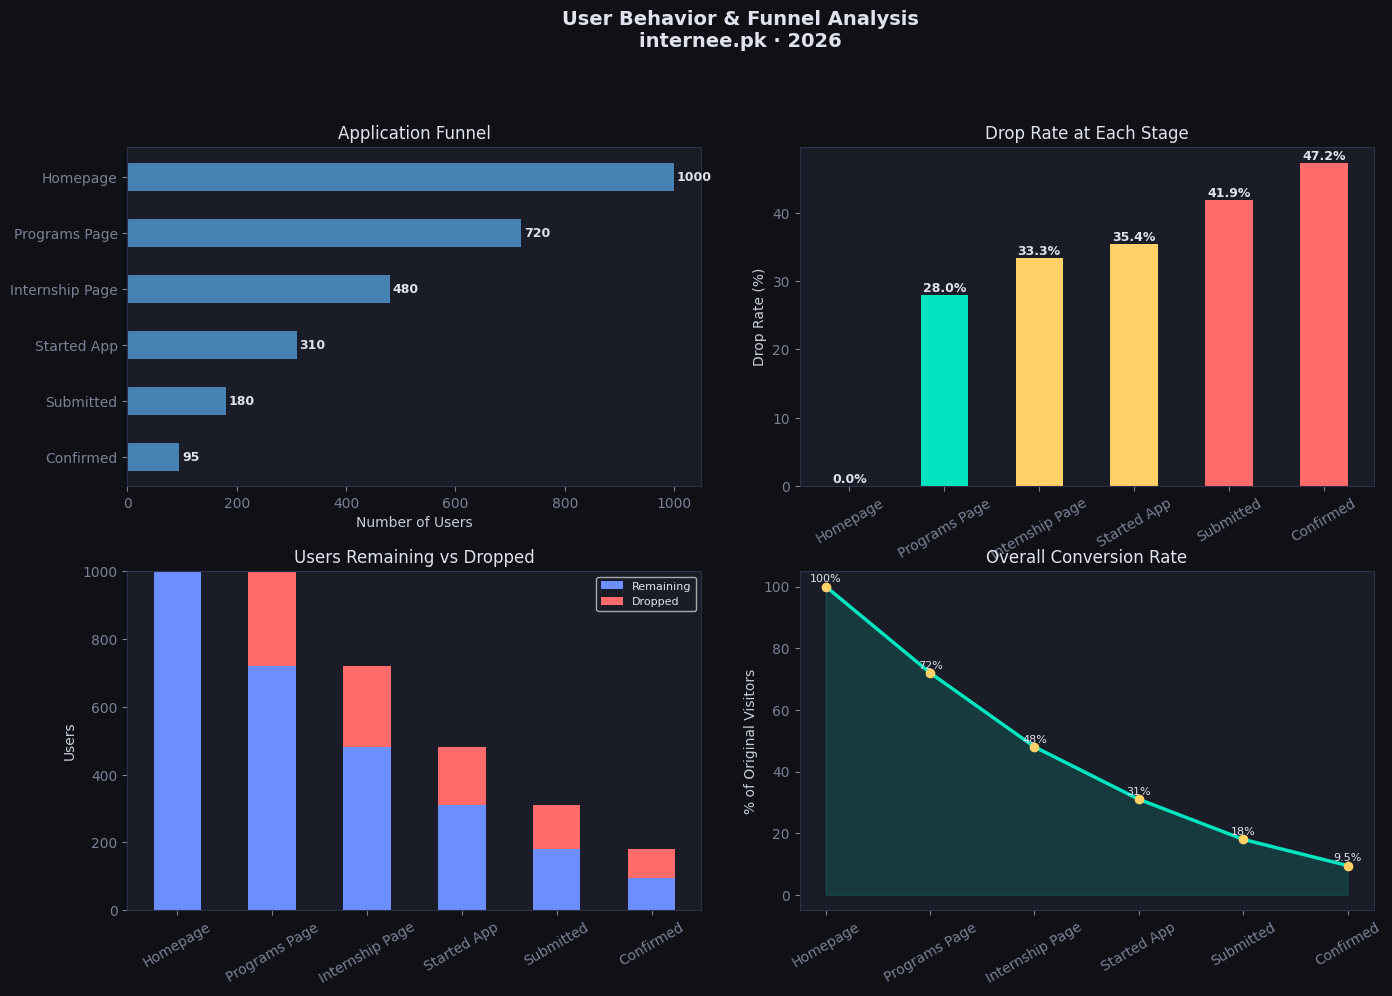

✅ Dashboard saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('User Behavior & Funnel Analysis\ninternee.pk · 2026',
             fontsize=14, fontweight='bold')
fig.tight_layout(pad=4)

# Chart 1 — Conversion Funnel (horizontal bar)
axes[0,0].barh(df['Stage'], df['Users'],
               color='steelblue', edgecolor='none', height=0.5)
for i, (users, stage) in enumerate(zip(df['Users'], df['Stage'])):
    axes[0,0].text(users + 5, i, str(users),
                   va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Application Funnel')
axes[0,0].set_xlabel('Number of Users')
axes[0,0].invert_yaxis()

# Chart 2 — Drop Rate at each stage (bar)
colors = ['#00e5c0' if x < 30 else '#ffd166' if x < 40 else '#ff6b6b'
          for x in df['Drop_Rate']]
axes[0,1].bar(df['Stage'], df['Drop_Rate'],
              color=colors, edgecolor='none', width=0.5)
for i, val in enumerate(df['Drop_Rate']):
    axes[0,1].text(i, val + 0.5, f'{val}%',
                   ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('Drop Rate at Each Stage')
axes[0,1].set_ylabel('Drop Rate (%)')
axes[0,1].tick_params(axis='x', rotation=30)

# Chart 3 — Users remaining vs dropped (stacked bar)
df['Remaining'] = df['Users']
axes[1,0].bar(df['Stage'], df['Users'],
              color='#6c8eff', edgecolor='none', width=0.5, label='Remaining')
axes[1,0].bar(df['Stage'], df['Dropped'],
              bottom=df['Users'], color='#ff6b6b',
              edgecolor='none', width=0.5, label='Dropped')
axes[1,0].set_title('Users Remaining vs Dropped')
axes[1,0].set_ylabel('Users')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(fontsize=8)

# Chart 4 — Overall conversion line
conversion = [100, 72, 48, 31, 18, 9.5]
axes[1,1].plot(df['Stage'], conversion,
               marker='o', color='#00e5c0', linewidth=2.5,
               markersize=7, markerfacecolor='#ffd166', markeredgecolor='none')
axes[1,1].fill_between(df['Stage'], conversion, alpha=0.15, color='#00e5c0')
for x, y in zip(df['Stage'], conversion):
    axes[1,1].text(x, y + 1.5, f'{y}%', ha='center', fontsize=8)
axes[1,1].set_title('Overall Conversion Rate')
axes[1,1].set_ylabel('% of Original Visitors')
axes[1,1].tick_params(axis='x', rotation=30)

plt.savefig('funnel_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")